<a href="https://colab.research.google.com/github/dougyd92/ML-Foudations/blob/main/Notebooks/16_Data_Augmentation_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation Demo
### See what augmented images look like, then measure the effect on accuracy

Quick demo: we'll train the same CNN on CIFAR-10 with and without data augmentation
and compare the results.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import time
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

print("Setup complete!")

Device: cuda
Setup complete!


---
# Section 1: What Data Augmentation Looks Like

Data augmentation applies **random transformations** to training images each time they're loaded.
The model never sees the exact same image twice — every epoch is a slightly different dataset.

Key idea: a horizontally flipped cat is still a cat. A slightly rotated, slightly cropped ship
is still a ship. We're teaching the model to be invariant to these transformations.

In [13]:
# Load CIFAR-10 WITHOUT any augmentation (just tensor conversion)
raw_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)

# Pick one image to augment repeatedly
sample_img, sample_label = raw_dataset[7]  # A horse
print(f"Sample image: {CIFAR_CLASSES[sample_label]}")
print(f"Shape: {sample_img.shape} (C, H, W)")

Sample image: horse
Shape: torch.Size([3, 32, 32]) (C, H, W)


### Common Augmentation Transforms

Each of these is **random** — every time you apply the transform pipeline to the same image,
you get a different result.

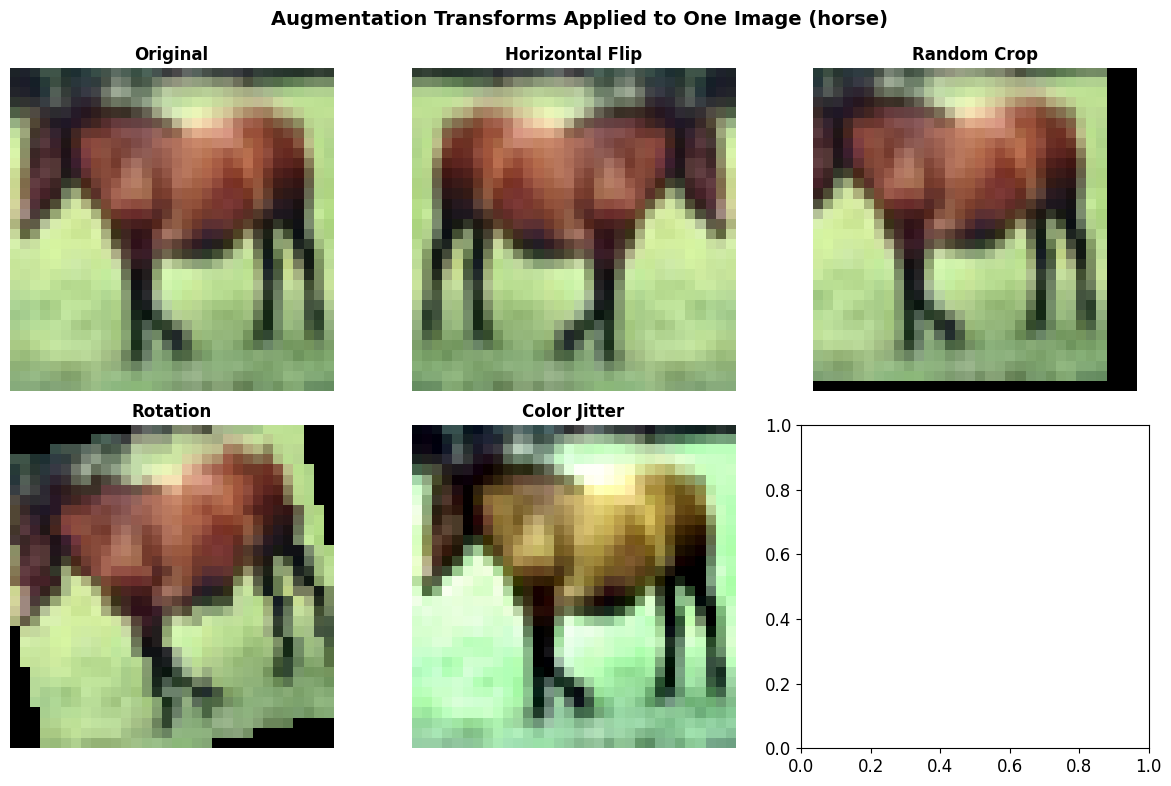

In [14]:
# Define individual augmentations so we can show each one
augmentations = {
    'Original':         transforms.Compose([]),
    'Horizontal Flip':  transforms.RandomHorizontalFlip(p=1.0),
    'Random Crop':      transforms.RandomCrop(32, padding=4),
    'Rotation':         transforms.RandomRotation(15),
    'Color Jitter':     transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                               saturation=0.3, hue=0.1),
    # 'Random Erasing':   transforms.Compose([transforms.RandomErasing(p=1.0, scale=(0.1, 0.25))]),
}

# Show each augmentation applied to the same image
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Convert tensor to PIL for transforms that expect PIL input
pil_img = transforms.ToPILImage()(sample_img)

for ax, (name, aug) in zip(axes.flat, augmentations.items()):
    if name == 'Random Erasing':
        # RandomErasing works on tensors, not PIL
        augmented = aug(sample_img.clone())
    elif name == 'Original':
        augmented = sample_img
    else:
        augmented = transforms.ToTensor()(aug(pil_img))

    ax.imshow(augmented.permute(1, 2, 0).numpy())
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axis('off')

fig.suptitle(f"Augmentation Transforms Applied to One Image ({CIFAR_CLASSES[sample_label]})",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### The Same Image, 15 Different Ways

In practice, we combine several transforms into a pipeline. Each time the dataloader
serves up an image, the pipeline runs with fresh random parameters. Here's what the model
sees across different epochs for a single training image:

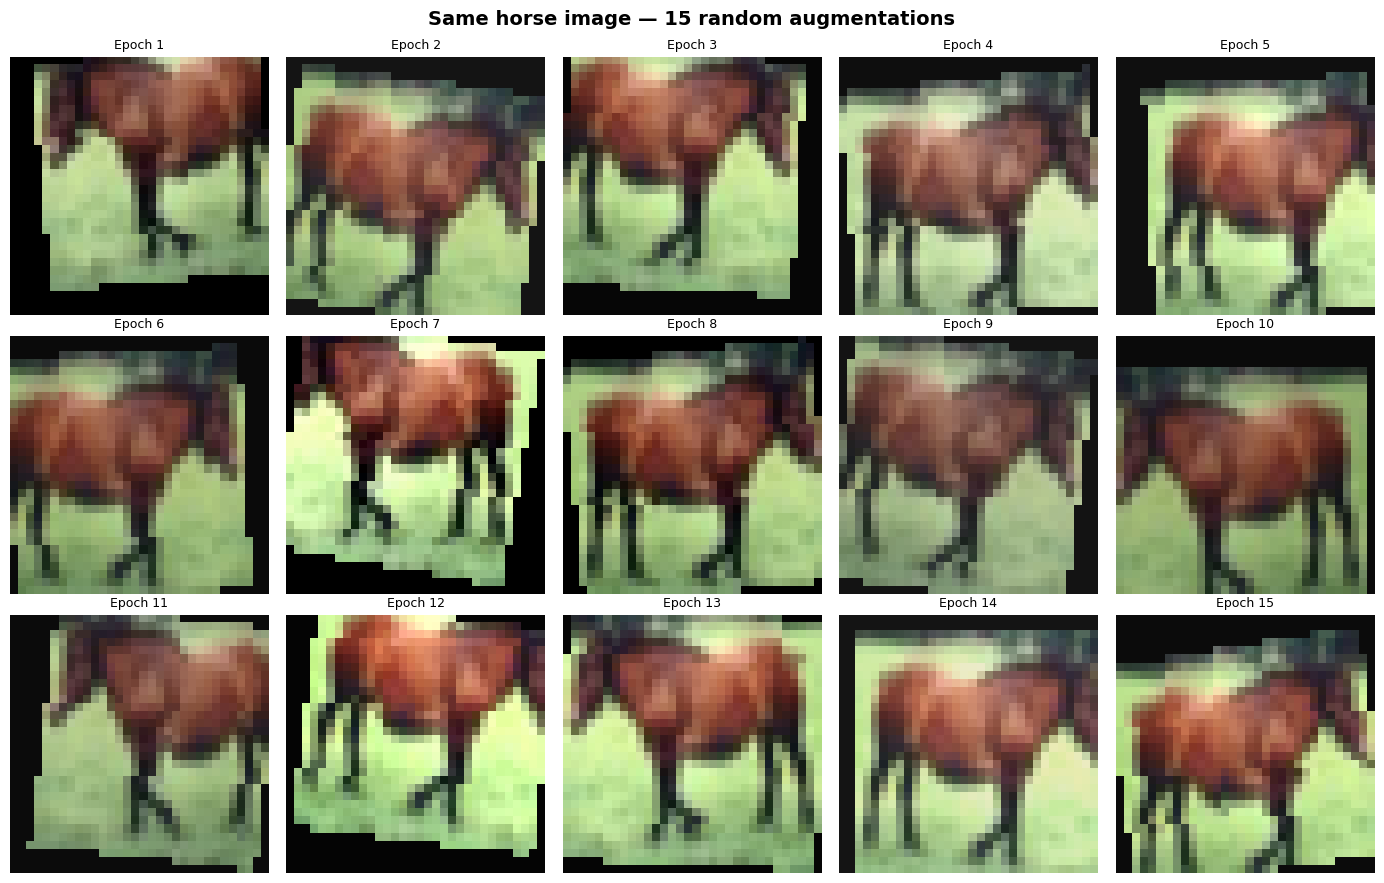

Every version is different, but they're all still clearly a horse.
The model learns to recognize the horse regardless of flip, crop, brightness, etc.


In [15]:
# The full augmentation pipeline we'll use for training
augment_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # transforms.RandomErasing(p=0.3, scale=(0.05, 0.15)),
])

# Apply it 15 times to the same image
fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for i, ax in enumerate(axes.flat):
    augmented = augment_pipeline(pil_img)
    ax.imshow(augmented.permute(1, 2, 0).numpy())
    ax.set_title(f"Epoch {i+1}", fontsize=9)
    ax.axis('off')

fig.suptitle(f"Same {CIFAR_CLASSES[sample_label]} image — 15 random augmentations",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Every version is different, but they're all still clearly a horse.")
print("The model learns to recognize the horse regardless of flip, crop, brightness, etc.")

---
# Section 2: Training With vs. Without Augmentation

Same CNN architecture, same optimizer, same number of epochs.
The only difference: one gets augmented training data, the other doesn't.

In [16]:
# Transform WITHOUT augmentation (baseline)
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Transform WITH augmentation
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    # transforms.RandomErasing(p=0.3, scale=(0.05, 0.15)),
])

# Test transform is NEVER augmented — we evaluate on clean images
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load datasets
train_no_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             transform=transform_no_aug)
train_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          transform=transform_test)

# Use a subset (5000 train, 1000 test) to keep training fast
torch.manual_seed(42)
train_idx = torch.randperm(len(train_no_aug))[:5000]
test_idx = torch.randperm(len(test_data))[:1000]

loader_no_aug = DataLoader(Subset(train_no_aug, train_idx), batch_size=64, shuffle=True, num_workers=2)
loader_aug = DataLoader(Subset(train_aug, train_idx), batch_size=64, shuffle=True, num_workers=2)
loader_test = DataLoader(Subset(test_data, test_idx), batch_size=64, shuffle=False, num_workers=2)

print(f"Training images: {len(train_idx)} (same subset for both)")
print(f"Test images:     {len(test_idx)}")

Training images: 5000 (same subset for both)
Test images:     1000


In [17]:
# A simple CNN (same architecture for both experiments)
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),

        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.3),

        nn.Flatten(),
        nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(128, 10)
    )

print(f"Parameters: {sum(p.numel() for p in make_cnn().parameters()):,}")

Parameters: 591,658


In [18]:
def train_and_evaluate(model, train_loader, test_loader, epochs, label):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_acc': [], 'test_acc': []}

    print(f"\n{'=' * 50}")
    print(f"Training: {label}")
    print(f"{'=' * 50}")

    for epoch in range(epochs):
        # Train
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
        train_acc = correct / total

        # Evaluate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                _, pred = model(images).max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()
        test_acc = correct / total

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train: {train_acc:.1%} | Test: {test_acc:.1%}")

    return history

In [19]:
# Train both models
NUM_EPOCHS = 200

torch.manual_seed(42)
model_no_aug = make_cnn()
hist_no_aug = train_and_evaluate(model_no_aug, loader_no_aug, loader_test,
                                  NUM_EPOCHS, "WITHOUT augmentation")

torch.manual_seed(42)
model_aug = make_cnn()
hist_aug = train_and_evaluate(model_aug, loader_aug, loader_test,
                               NUM_EPOCHS, "WITH augmentation")


Training: WITHOUT augmentation
Epoch  1/200 | Train: 23.3% | Test: 39.1%
Epoch  2/200 | Train: 32.2% | Test: 42.0%
Epoch  3/200 | Train: 37.4% | Test: 46.6%
Epoch  4/200 | Train: 40.5% | Test: 48.6%
Epoch  5/200 | Train: 42.1% | Test: 49.7%
Epoch  6/200 | Train: 43.6% | Test: 50.5%
Epoch  7/200 | Train: 46.1% | Test: 52.4%
Epoch  8/200 | Train: 47.1% | Test: 55.3%
Epoch  9/200 | Train: 50.2% | Test: 56.7%
Epoch 10/200 | Train: 50.1% | Test: 57.3%
Epoch 11/200 | Train: 52.9% | Test: 57.1%
Epoch 12/200 | Train: 54.2% | Test: 57.1%
Epoch 13/200 | Train: 54.1% | Test: 57.7%
Epoch 14/200 | Train: 56.4% | Test: 58.4%
Epoch 15/200 | Train: 57.0% | Test: 60.5%
Epoch 16/200 | Train: 57.4% | Test: 57.0%
Epoch 17/200 | Train: 58.6% | Test: 60.8%
Epoch 18/200 | Train: 58.5% | Test: 60.9%
Epoch 19/200 | Train: 59.6% | Test: 59.9%
Epoch 20/200 | Train: 61.0% | Test: 61.3%
Epoch 21/200 | Train: 61.7% | Test: 60.7%
Epoch 22/200 | Train: 62.8% | Test: 62.2%
Epoch 23/200 | Train: 61.8% | Test: 61.9%
Ep

### Results

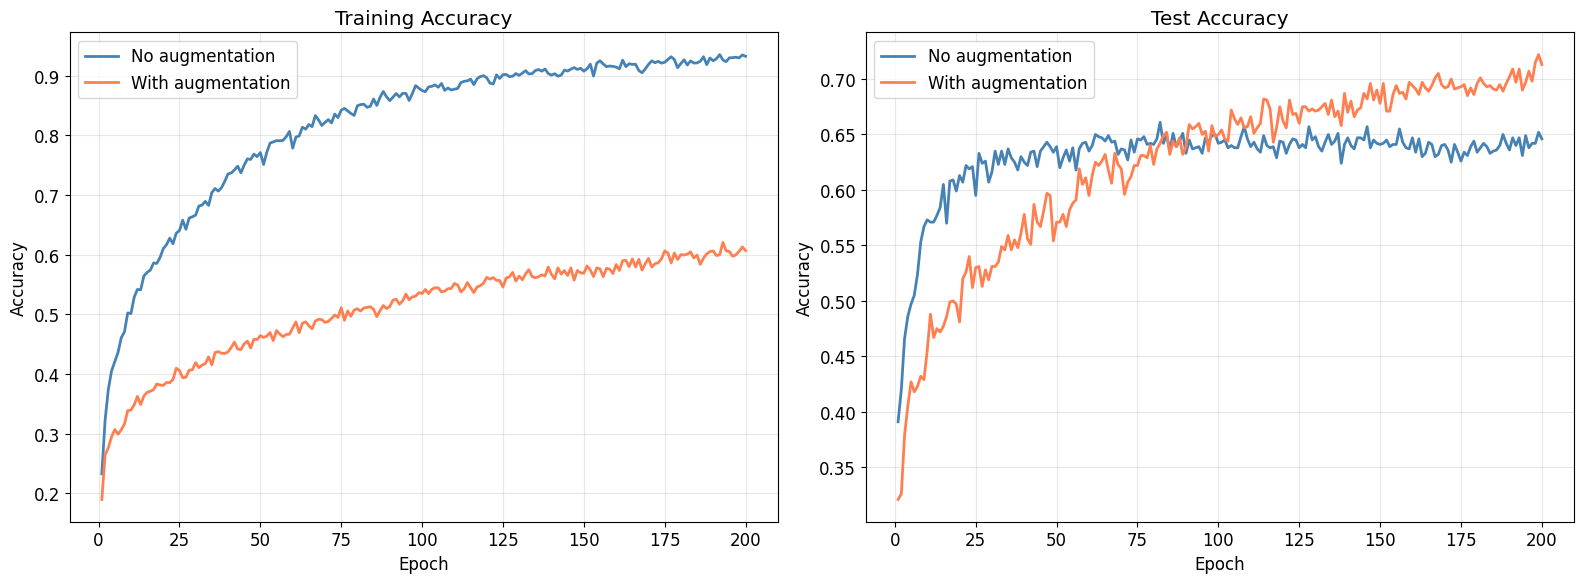

Final test accuracy WITHOUT augmentation: 64.6%
Final test accuracy WITH augmentation:    71.3%
Improvement: +6.7%


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, NUM_EPOCHS + 1)

# Training accuracy
ax1.plot(epochs, hist_no_aug['train_acc'], '-', color='steelblue', linewidth=2, label='No augmentation')
ax1.plot(epochs, hist_aug['train_acc'], '-', color='coral', linewidth=2, label='With augmentation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Test accuracy
ax2.plot(epochs, hist_no_aug['test_acc'], '-', color='steelblue', linewidth=2, label='No augmentation')
ax2.plot(epochs, hist_aug['test_acc'], '-', color='coral', linewidth=2, label='With augmentation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final test accuracy WITHOUT augmentation: {hist_no_aug['test_acc'][-1]:.1%}")
print(f"Final test accuracy WITH augmentation:    {hist_aug['test_acc'][-1]:.1%}")
print(f"Improvement: {hist_aug['test_acc'][-1] - hist_no_aug['test_acc'][-1]:+.1%}")

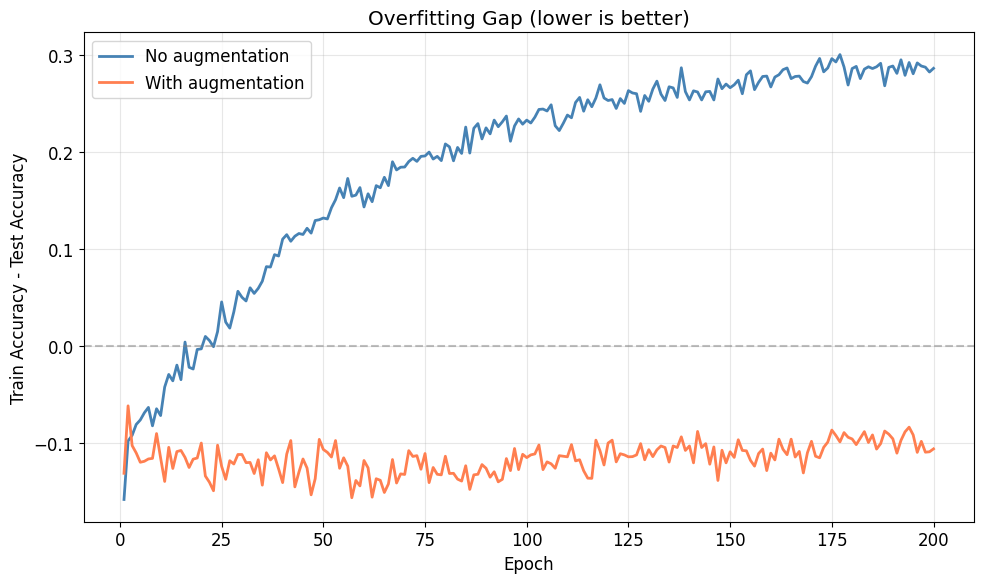

Without augmentation: training accuracy climbs high, but test accuracy stalls or drops.
With augmentation: the gap stays smaller — the model generalizes better.


In [21]:
# The gap between train and test tells the overfitting story
fig, ax = plt.subplots(figsize=(10, 6))

gap_no_aug = [t - v for t, v in zip(hist_no_aug['train_acc'], hist_no_aug['test_acc'])]
gap_aug = [t - v for t, v in zip(hist_aug['train_acc'], hist_aug['test_acc'])]

ax.plot(epochs, gap_no_aug, '-', color='steelblue', linewidth=2, label='No augmentation')
ax.plot(epochs, gap_aug, '-', color='coral', linewidth=2, label='With augmentation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Accuracy - Test Accuracy')
ax.set_title('Overfitting Gap (lower is better)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Without augmentation: training accuracy climbs high, but test accuracy stalls or drops.")
print("With augmentation: the gap stays smaller — the model generalizes better.")

---
# Summary

**Data augmentation** applies random transformations (flips, crops, rotations, color changes, erasure)
to training images. The test data is never augmented.

**Why it works:** the model never memorizes exact pixel patterns. It's forced to learn features
that are invariant to position, orientation, brightness, and small occlusions.

**What we saw:**
- Without augmentation: high training accuracy, lower test accuracy (overfitting)
- With augmentation: training accuracy is lower (the task is harder!), but test accuracy is higher

**Key details:**
- Augmentation is a **regularization** technique, like dropout or weight decay
- Only applied during **training**, never during evaluation
- Each epoch the model sees a different version of each image
- Doesn't create a larger dataset — it creates a more *diverse* view of the same data

**For Project 4:** EMNIST images are grayscale handwritten letters. Useful augmentations include
small rotations, slight shifts (RandomAffine), and random erasing. Horizontal flips would
turn some letters into others (b/d, p/q), so use with caution or skip them.